# ConvNeXt-Tiny — Full ML Pipeline

Single-model notebook for the certification. Covers every stage in order:

1. Data split (70 % train / 15 % val / 15 % **held-out test**)
2. Training — two-phase strategy (feature extraction → full fine-tuning)
3. StratifiedKFold — stability validation across 5 splits
4. Diagnostics — per-class F1 & precision heatmaps
5. Held-out test set — final unbiased evaluation

**Why ConvNeXt-Tiny?**
Benchmark over 5 architectures gave:  ConvNeXt-Tiny 95.4 % | EfficientNet-B3 92.9 % | EfficientNet-B4 92.8 %.
McNemar's test confirmed the gap is statistically significant (p < 0.05).
KFold (5 folds) confirmed stability: 0.9524 ± 0.0012.

In [1]:
# ============================================
# Setup Colab: GPU + Drive
# ============================================

import os
from pathlib import Path

COLAB = "google.colab" in str(get_ipython())

if COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    !nvidia-smi
else:
    print("Running locally")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wed Apr 15 18:07:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   31C    P0             47W /  600W |       0MiB /  97887MiB |      0%      Default |
|          

In [4]:
# ============================================
# Paths
# ============================================

if COLAB:
    DRIVE_ROOT        = Path("/content/drive/MyDrive/bootcamp_project/data/")
    LOCAL_SSD_ROOT    = Path("/content/dataset/")
    DRIVE_DATASET_DIR = DRIVE_ROOT
    LOCAL_DATASET_DIR = LOCAL_SSD_ROOT
else:
    LOCAL_DATASET_DIR = Path("data/dataset")

SPLIT_DIR  = Path("/content/dataset_split") if COLAB else Path("data/dataset_split")
TRAIN_DIR  = SPLIT_DIR / "train"
VAL_DIR    = SPLIT_DIR / "val"
TEST_DIR   = SPLIT_DIR / "test"   # locked until final evaluation

### Fast Data Loading via Tarball

Copying 57 000+ individual files to the local SSD is slow.
A single compressed archive is created once on Drive and extracted each session — much faster.

In [11]:
import shutil

tar_filename   = "dataset.tar.gz"
DRIVE_TAR_PATH = DRIVE_DATASET_DIR / tar_filename
LOCAL_TAR_PATH = LOCAL_SSD_ROOT / tar_filename

if COLAB:
    LOCAL_SSD_ROOT.mkdir(parents=True, exist_ok=True)
    print("--- Fast Dataset Loading ---")
    if not DRIVE_TAR_PATH.exists():
        print(f"Creating tarball on Drive (first time only)...")
        import tarfile
        with tarfile.open(DRIVE_TAR_PATH, "w:gz") as tar:
            tar.add(DRIVE_DATASET_DIR, arcname=DRIVE_DATASET_DIR.name)
        print("Tarball created.")
    else:
        print("Tarball found on Drive.")

    if not LOCAL_DATASET_DIR.exists():
        print("Copying tarball to local SSD...")
        shutil.copy2(DRIVE_TAR_PATH, LOCAL_TAR_PATH)
        print("Extracting...")
        import tarfile
        with tarfile.open(LOCAL_TAR_PATH, "r:gz") as tar:
            tar.extractall(LOCAL_SSD_ROOT)
        LOCAL_TAR_PATH.unlink()
        print(f"Done. Dataset at {LOCAL_DATASET_DIR}")
    else:
        print("Dataset already on local SSD.")

--- Fast Dataset Loading ---
Tarball found on Drive.
Dataset already on local SSD.


In [6]:
import shutil

tar_filename = "dataset.tar.gz"
DRIVE_TAR_PATH = DRIVE_DATASET_DIR / tar_filename
LOCAL_TAR_PATH = LOCAL_SSD_ROOT / tar_filename

if COLAB:
    print("\n--- Optimizing Dataset Loading ---")
    print("Checking for dataset tarball on Drive...")
    if not DRIVE_TAR_PATH.exists():
        print(f"Creating tarball '{tar_filename}' from '{DRIVE_DATASET_DIR.name}' in '{DRIVE_DATASET_DIR.parent}'...")
        # Create a tar.gz archive of the dataset directory
        shutil.make_archive(
            str(DRIVE_TAR_PATH.with_suffix('')), # make_archive adds .tar.gz itself
            'gztar',
            root_dir=DRIVE_DATASET_DIR.parent, # The directory containing the folder to archive
            base_dir=DRIVE_DATASET_DIR.name   # The folder to archive
        )
        print(f"✓ Tarball created at {DRIVE_TAR_PATH}")
    else:
        print(f"✓ Tarball already exists at {DRIVE_TAR_PATH}")

    # Check if LOCAL_DATASET_DIR is already populated to skip re-extraction
    # This is useful if a previous run in the same session already extracted the data
    if LOCAL_DATASET_DIR.exists() and any(LOCAL_DATASET_DIR.iterdir()): # Check if directory exists and is not empty
        print("✓ Local dataset directory is already populated. Skipping tarball extraction.")
    else:
        LOCAL_SSD_ROOT.mkdir(parents=True, exist_ok=True)
        print(f"Copying tarball from Drive to local SSD: {DRIVE_TAR_PATH} -> {LOCAL_TAR_PATH}")
        shutil.copy2(DRIVE_TAR_PATH, LOCAL_TAR_PATH)
        print(f"✓ Tarball copied to local SSD.")

        print(f"Extracting tarball to {LOCAL_SSD_ROOT}...")
        shutil.unpack_archive(LOCAL_TAR_PATH, LOCAL_SSD_ROOT)
        print(f"✓ Tarball extracted.")

        # Clean up the copied tarball to save space on SSD
        LOCAL_TAR_PATH.unlink()
        print(f"✓ Local tarball removed: {LOCAL_TAR_PATH}")

    print("--- Dataset loading optimization complete ---")
else:
    print("Local run — no tarball needed.")


--- Optimizing Dataset Loading ---
Checking for dataset tarball on Drive...
✓ Tarball already exists at /content/drive/MyDrive/bootcamp_project/data/dataset.tar.gz
Copying tarball from Drive to local SSD: /content/drive/MyDrive/bootcamp_project/data/dataset.tar.gz -> /content/dataset/dataset.tar.gz
✓ Tarball copied to local SSD.
Extracting tarball to /content/dataset...
✓ Tarball extracted.
✓ Local tarball removed: /content/dataset/dataset.tar.gz
--- Dataset loading optimization complete ---


In [7]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jimmy-ouellet (jimmy-ouellet-personnal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [8]:
! pip install -q timm

In [9]:
# ============================================
# Imports
# ============================================

import os, glob, pickle
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset as TorchDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

import timm
import wandb
import scipy.stats as stats
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, classification_report,
                              confusion_matrix)
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [10]:
# ============================================
# ConvNeXt-Tiny Configuration
# ============================================
# Winner of the 5-model benchmark (val_acc = 0.9540).
# Native resolution 224 px; fits 64 images per batch on a T4/A100.

MODEL_KEY   = "convnext_tiny"
TIMM_NAME   = "convnext_tiny"
IMG_SIZE    = 224
BATCH_SIZE  = 64

# Training phases
PHASE1_EPOCHS = 5    # frozen backbone — head only
PHASE2_EPOCHS = 15   # full fine-tuning

# KFold
K_FOLDS      = 5
KF_PHASE1_EP = 3
KF_PHASE2_EP = 10
RANDOM_STATE = 42

print(f"Model: {MODEL_KEY}  img={IMG_SIZE}px  batch={BATCH_SIZE}")

Model: convnext_tiny  img=224px  batch=64


## Step 1 — Data Split  (70 / 15 / 15)

| Split | Purpose | Influences model? |
|---|---|---|
| Train 70 % | Weight updates | Yes — directly |
| Val 15 % | Checkpoint selection | Yes — indirectly |
| **Test 15 %** | **Final unbiased evaluation** | **Never** |

The test directory is created here and not opened again until the very last section.

In [13]:
# ============================================
# Stratified 70 / 15 / 15 Split
# ============================================
# Two sequential train_test_split calls, both with random_state=42
# so the split is deterministic and reproducible.
# Step 1: set aside 15 % as the held-out test set.
# Step 2: split the remaining 85 % into 70 % train and 15 % val.
#         (85 % × 17.6 % ≈ 15 %  →  final proportions: 70 / 15 / 15)

import os, shutil
from tqdm import tqdm

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)
LOCAL_DATASET_DIR = Path("/content/dataset/dataset/")
classes = sorted([
    d.name for d in LOCAL_DATASET_DIR.iterdir()
    if d.is_dir() and not d.name.startswith(".")
])
print(f"{len(classes)} classes found.")

for cls in tqdm(classes, desc="Splitting"):
    src    = LOCAL_DATASET_DIR / cls
    images = [f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    trainval, test  = train_test_split(images,   test_size=0.15,  random_state=RANDOM_STATE)
    train,    val   = train_test_split(trainval,  test_size=0.176, random_state=RANDOM_STATE)

    for split_dir, imgs in [(TRAIN_DIR, train), (VAL_DIR, val), (TEST_DIR, test)]:
        (split_dir / cls).mkdir(parents=True, exist_ok=True)
        for img in imgs:
            shutil.copy2(src / img, split_dir / cls / img)

print()
for label, d in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    total = sum(len(list((d / cls).iterdir())) for cls in classes)
    print(f"  {label:<6}: {total:>6} images  (~{total / (total * 3 / 2):.0%})")

58 classes found.


Splitting: 100%|██████████| 58/58 [00:03<00:00, 19.33it/s]


  Train :  41200 images  (~67%)
  Val   :   8830 images  (~67%)
  Test  :   8841 images  (~67%)


In [14]:
# ============================================
# Base Dataset Metadata + Class Weights
# ============================================

_ref_ds      = ImageFolder(TRAIN_DIR)
num_classes  = len(_ref_ds.classes)
class_names  = _ref_ds.classes
idx_to_class = {v: k for k, v in _ref_ds.class_to_idx.items()}

print(f"{num_classes} classes | {len(_ref_ds)} train images")

# Class-imbalance weights — Effective Number of Samples (Cui et al., 2019)
class_counts2 = Counter(_ref_ds.targets)
class_counts  = np.array(list(class_counts2.values()))
beta          = 0.9999
effective_num = 1.0 - np.power(beta, class_counts)
weights       = (1.0 - beta) / effective_num
weights       = weights / weights.sum() * num_classes
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"Class counts — min: {class_counts.min()}  max: {class_counts.max()}  mean: {class_counts.mean():.0f}")
print(f"Class weights — range: [{weights.min():.3f}, {weights.max():.3f}]")

58 classes | 41200 train images
Class counts — min: 297  max: 1105  mean: 710
Class weights — range: [0.630, 2.251]


In [15]:
# ============================================
# Data Augmentation
# ============================================

def get_transforms(img_size: int = IMG_SIZE):
    train_tfm = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
        transforms.RandomPerspective(distortion_scale=0.3, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tfm = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_tfm, val_tfm

In [16]:
# ============================================
# Mixup
# ============================================

def mixup_data(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0
    lam      = np.random.beta(alpha, alpha)
    index    = torch.randperm(x.size(0))
    mixed_x  = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [17]:
# ============================================
# Model Factory + Freeze / Unfreeze
# ============================================

def get_model(timm_name: str = TIMM_NAME) -> nn.Module:
    m = timm.create_model(timm_name, pretrained=True, num_classes=num_classes)
    return m.to(device)

def freeze_backbone(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.get_classifier().parameters():
        p.requires_grad = True

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

In [18]:
# ============================================
# Training Utilities
# ============================================

def make_loaders(train_dir, val_dir, batch_size=BATCH_SIZE):
    tr_tfm, va_tfm = get_transforms()
    tr_ld = DataLoader(ImageFolder(train_dir, transform=tr_tfm),
                       batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
    va_ld = DataLoader(ImageFolder(val_dir,   transform=va_tfm),
                       batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
    return tr_ld, va_ld

def train_one_epoch(model, loader, optimizer, criterion, mixup_alpha=0.2):
    model.train()
    total, correct, total_loss = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        x, y_a, y_b, lam = mixup_data(x, y, alpha=mixup_alpha)
        optimizer.zero_grad()
        preds = model(x)
        loss  = mixup_criterion(criterion, preds, y_a, y_b, lam)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        _, predicted = preds.max(1)
        correct += (lam * predicted.eq(y_a).sum().item()
                    + (1 - lam) * predicted.eq(y_b).sum().item())
        total += x.size(0)
    return total_loss / total, correct / total

def validate(model, loader, criterion):
    model.eval()
    total, correct, total_loss = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss  = criterion(preds, y)
            total_loss += loss.item() * x.size(0)
            _, predicted = preds.max(1)
            correct += predicted.eq(y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total

## Step 2 — Training

In [22]:
# ============================================
# Two-Phase Training
# ============================================
# Phase 1: backbone frozen → train the classification head only.
#          Fast convergence without destroying ImageNet features.
# Phase 2: all layers unfrozen → fine-tune at 10x lower LR.
#          Adapts backbone features to the 59-class plant dataset.

train_loader, val_loader = make_loaders(TRAIN_DIR, VAL_DIR)
model     = get_model()
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
ckpt_path = f"{MODEL_KEY}_best.pth"
best_acc  = 0.0
step      = 0

run = wandb.init(
    project="certification",
    name=MODEL_KEY,
    config={
        "model": MODEL_KEY, "timm_name": TIMM_NAME,
        "img_size": IMG_SIZE, "batch_size": BATCH_SIZE,
        "phase1_epochs": PHASE1_EPOCHS, "phase2_epochs": PHASE2_EPOCHS,
        "optimizer": "Adam", "scheduler": "CosineAnnealingLR",
        "mixup_alpha": 0.2, "label_smoothing": 0.1,
        "num_classes": num_classes, "split": "70/15/15",
    },
    reinit="finish_previous",
)

# ── Phase 1 ──────────────────────────────────────────────────────────────────
print(f"[Phase 1] Feature extraction — {PHASE1_EPOCHS} epochs")
freeze_backbone(model)
optimizer = optim.Adam(model.get_classifier().parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=PHASE1_EPOCHS)

for epoch in range(PHASE1_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = validate(model, val_loader, criterion)
    scheduler.step()
    print(f"  P1 {epoch+1:02d}/{PHASE1_EPOCHS} | train {tr_acc:.3f} | val {va_acc:.3f}")
    wandb.log({"phase": 1, "epoch": epoch+1,
               "train_loss": tr_loss, "train_acc": tr_acc,
               "val_loss": va_loss,   "val_acc": va_acc}, step=step)
    step += 1

# ── Phase 2 ──────────────────────────────────────────────────────────────────
print(f"[Phase 2] Full fine-tuning — {PHASE2_EPOCHS} epochs")
unfreeze_all(model)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS)

for epoch in range(PHASE2_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    va_loss, va_acc = validate(model, val_loader, criterion)
    scheduler.step()
    print(f"P2 {epoch+1:02d}/{PHASE2_EPOCHS} | train {tr_acc:.3f} | val {va_acc:.3f}")
    wandb.log({"phase": 2, "epoch": PHASE1_EPOCHS + epoch+1,
               "train_loss": tr_loss, "train_acc": tr_acc,
               "val_loss": va_loss,   "val_acc": va_acc}, step=step)
    step += 1

    if va_acc > best_acc:
        best_acc = va_acc
        torch.save(model.state_dict(), ckpt_path)
        art = wandb.Artifact(f"{MODEL_KEY}_best", type="model",
                             metadata={"val_acc": best_acc, "split": "70/15/15"})
        art.add_file(ckpt_path)
        wandb.log_artifact(art)
        print(f"  ✓ Best checkpoint  val_acc={best_acc:.4f}")

wandb.summary["best_val_acc"] = best_acc
run.finish()
print(f"Training complete. Best val_acc = {best_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

[Phase 1] Feature extraction — 5 epochs
  P1 01/5 | train 0.707 | val 0.886
  P1 02/5 | train 0.769 | val 0.892
  P1 03/5 | train 0.789 | val 0.902
  P1 04/5 | train 0.784 | val 0.905
  P1 05/5 | train 0.807 | val 0.912
[Phase 2] Full fine-tuning — 15 epochs
P2 01/15 | train 0.765 | val 0.890
  ✓ Best checkpoint  val_acc=0.8897
P2 02/15 | train 0.809 | val 0.908
  ✓ Best checkpoint  val_acc=0.9084
P2 03/15 | train 0.833 | val 0.917
  ✓ Best checkpoint  val_acc=0.9171
P2 04/15 | train 0.841 | val 0.916
P2 05/15 | train 0.855 | val 0.926
  ✓ Best checkpoint  val_acc=0.9258
P2 06/15 | train 0.860 | val 0.930
  ✓ Best checkpoint  val_acc=0.9296
P2 07/15 | train 0.868 | val 0.928
P2 08/15 | train 0.870 | val 0.934
  ✓ Best checkpoint  val_acc=0.9344
P2 09/15 | train 0.879 | val 0.940
  ✓ Best checkpoint  val_acc=0.9403
P2 10/15 | train 0.879 | val 0.948
  ✓ Best checkpoint  val_acc=0.9484
P2 11/15 | train 0.891 | val 0.948
P2 12/15 | train 0.895 | val 0.953
  ✓ Best checkpoint  val_acc=0.95

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
phase,▁▁▁▁▁███████████████
train_acc,▁▃▄▄▅▃▅▆▆▆▇▇▇▇▇███▇█
train_loss,█▆▅▆▅▆▄▃▃▃▂▂▂▂▂▁▁▁▁▁
val_acc,▁▂▃▃▄▁▃▄▄▅▅▅▆▆▇▇████
val_loss,█▇▇▆▆▅▄▄▃▃▃▃▂▂▂▁▁▁▁▁
best_val_acc,0.95572
epoch,20
phase,2
train_acc,0.89494
train_loss,1.11699


Training complete. Best val_acc = 0.9557


## Step 3 — StratifiedKFold Stability Validation

Trains ConvNeXt-Tiny from scratch on 5 different train/val splits of the
**train + val pool** (the test set is excluded from KFold entirely).

A standard deviation < 0.005 across folds confirms that the benchmark accuracy
is not an artifact of a lucky split — a strong claim to make to the jury.

In [23]:
# ============================================
# PathDataset — per-fold transforms
# ============================================

class PathDataset(TorchDataset):
    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# Combine train + val (exclude test)
_tr = ImageFolder(TRAIN_DIR)
_va = ImageFolder(VAL_DIR)
_all_samples = [(str(p), l) for p, l in _tr.samples] + [(str(p), l) for p, l in _va.samples]
_all_targets = [l for _, l in _all_samples]
print(f"KFold pool: {len(_all_samples)} images (train + val, test excluded)")

KFold pool: 50030 images (train + val, test excluded)


In [25]:
# ============================================
# StratifiedKFold — 5 folds
# ============================================

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_STATE)
targets_arr  = np.array(_all_targets)
kfold_results = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(targets_arr)), targets_arr)):
    print(f"{'─'*55}")
    print(f"  Fold {fold+1}/{K_FOLDS}  |  train {len(tr_idx)}  val {len(va_idx)}")
    print(f"{'─'*55}")

    tr_tfm, va_tfm = get_transforms()
    tr_ld = DataLoader(PathDataset([_all_samples[i] for i in tr_idx], tr_tfm),
                       batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
    va_ld = DataLoader(PathDataset([_all_samples[i] for i in va_idx], va_tfm),
                       batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

    fold_model = get_model()
    criterion  = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    best_fold_acc = 0.0
    step = 0

    fold_run = wandb.init(
        project="certification", name=f"{MODEL_KEY}_fold{fold+1}",
        group=f"{MODEL_KEY}_kfold",
        config={"fold": fold+1, "k_folds": K_FOLDS, "model": MODEL_KEY,
                "phase1_epochs": KF_PHASE1_EP, "phase2_epochs": KF_PHASE2_EP},
        reinit="finish_previous",
    )

    # Phase 1
    freeze_backbone(fold_model)
    opt = optim.Adam(fold_model.get_classifier().parameters(), lr=1e-3)
    sch = CosineAnnealingLR(opt, T_max=KF_PHASE1_EP)
    for epoch in range(KF_PHASE1_EP):
        tl, ta = train_one_epoch(fold_model, tr_ld, opt, criterion)
        vl, va = validate(fold_model, va_ld, criterion)
        sch.step()
        print(f"  P1 {epoch+1:02d}/{KF_PHASE1_EP} | train {ta:.3f} | val {va:.3f}")
        wandb.log({"phase": 1, "epoch": epoch+1,
                   "train_loss": tl, "train_acc": ta, "val_loss": vl, "val_acc": va}, step=step)
        step += 1

    # Phase 2
    unfreeze_all(fold_model)
    opt = optim.Adam(fold_model.parameters(), lr=1e-4)
    sch = CosineAnnealingLR(opt, T_max=KF_PHASE2_EP)
    for epoch in range(KF_PHASE2_EP):
        tl, ta = train_one_epoch(fold_model, tr_ld, opt, criterion)
        vl, va = validate(fold_model, va_ld, criterion)
        sch.step()
        print(f"  P2 {epoch+1:02d}/{KF_PHASE2_EP} | train {ta:.3f} | val {va:.3f}")
        wandb.log({"phase": 2, "epoch": KF_PHASE1_EP + epoch+1,
                   "train_loss": tl, "train_acc": ta, "val_loss": vl, "val_acc": va}, step=step)
        step += 1
        if va > best_fold_acc:
            best_fold_acc = va

    wandb.summary["best_val_acc"] = best_fold_acc
    fold_run.finish()
    kfold_results.append({"fold": fold+1, "best_val_acc": best_fold_acc})
    print(f"  Fold {fold+1} done — best_val_acc={best_fold_acc:.4f}")

───────────────────────────────────────────────────────
  Fold 1/5  |  train 40024  val 10006
───────────────────────────────────────────────────────


  P1 01/3 | train 0.711 | val 0.882
  P1 02/3 | train 0.766 | val 0.896
  P1 03/3 | train 0.788 | val 0.902
  P2 01/10 | train 0.753 | val 0.887
  P2 02/10 | train 0.795 | val 0.900
  P2 03/10 | train 0.831 | val 0.917
  P2 04/10 | train 0.844 | val 0.924
  P2 05/10 | train 0.865 | val 0.933
  P2 06/10 | train 0.873 | val 0.945
  P2 07/10 | train 0.873 | val 0.947
  P2 08/10 | train 0.877 | val 0.951
  P2 09/10 | train 0.888 | val 0.954
  P2 10/10 | train 0.890 | val 0.954


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
phase,▁▁▁██████████
train_acc,▁▃▄▃▄▆▆▇▇▇▇██
train_loss,█▆▆▆▄▃▃▂▂▂▁▁▁
val_acc,▁▂▃▁▃▄▅▆▇▇███
val_loss,█▇▆▆▅▄▃▂▂▂▁▁▁
best_val_acc,0.95443
epoch,13
phase,2
train_acc,0.8901
train_loss,1.15309


  Fold 1 done — best_val_acc=0.9544
───────────────────────────────────────────────────────
  Fold 2/5  |  train 40024  val 10006
───────────────────────────────────────────────────────


  P1 01/3 | train 0.707 | val 0.879
  P1 02/3 | train 0.769 | val 0.890
  P1 03/3 | train 0.798 | val 0.898
  P2 01/10 | train 0.763 | val 0.889
  P2 02/10 | train 0.810 | val 0.895
  P2 03/10 | train 0.827 | val 0.907
  P2 04/10 | train 0.844 | val 0.919
  P2 05/10 | train 0.864 | val 0.924
  P2 06/10 | train 0.876 | val 0.931
  P2 07/10 | train 0.882 | val 0.935
  P2 08/10 | train 0.890 | val 0.942
  P2 09/10 | train 0.895 | val 0.945
  P2 10/10 | train 0.885 | val 0.947


...

epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
phase,▁▁▁██████████
train_acc,▁▄▄▃▅▅▇▇▇████
train_loss,█▅▆▆▄▄▂▂▂▂▁▁▁
val_acc,▁▂▃▂▅▃▅▅▆▇███
val_loss,█▇▆▆▄▄▃▃▂▂▁▁▁
best_val_acc,0.94953
epoch,13
phase,2
train_acc,0.88971
train_loss,1.14906


  Fold 4 done — best_val_acc=0.9495
───────────────────────────────────────────────────────
  Fold 5/5  |  train 40024  val 10006
───────────────────────────────────────────────────────


  P1 01/3 | train 0.705 | val 0.877
  P1 02/3 | train 0.775 | val 0.888
  P1 03/3 | train 0.779 | val 0.901
  P2 01/10 | train 0.755 | val 0.891
  P2 02/10 | train 0.807 | val 0.903
  P2 03/10 | train 0.823 | val 0.912
  P2 04/10 | train 0.848 | val 0.920
  P2 05/10 | train 0.862 | val 0.920
  P2 06/10 | train 0.878 | val 0.930
  P2 07/10 | train 0.876 | val 0.940
  P2 08/10 | train 0.890 | val 0.942
  P2 09/10 | train 0.894 | val 0.946
  P2 10/10 | train 0.890 | val 0.949


epoch,▁▂▂▃▃▄▅▅▆▆▇▇█
phase,▁▁▁██████████
train_acc,▁▄▄▃▅▅▆▇▇▇███
train_loss,█▆▆▆▄▄▃▂▂▂▁▁▁
val_acc,▁▂▃▂▄▄▅▅▆▇▇██
val_loss,█▇▆▅▄▄▃▃▂▁▁▁▁
best_val_acc,0.94863
epoch,13
phase,2
train_acc,0.89043
train_loss,1.1491


  Fold 5 done — best_val_acc=0.9486


In [26]:
# ============================================
# KFold Summary
# ============================================

kfold_df = pd.DataFrame(kfold_results)
accs     = kfold_df["best_val_acc"].values

print("\n" + "="*50)
print(f"  Model   : {MODEL_KEY}")
print(f"  Folds   : {K_FOLDS}")
print(f"  Val acc : {accs.mean():.4f} ± {accs.std():.4f}")
print(f"  Per fold: {[round(a, 4) for a in accs]}")
print("="*50)

kf_run = wandb.init(project="certification", name=f"{MODEL_KEY}_kfold_summary",
                    reinit="finish_previous")
wandb.log({"kfold_mean_val_acc": accs.mean(), "kfold_std_val_acc": accs.std(),
           "kfold_results": wandb.Table(dataframe=kfold_df)})
kf_run.finish()


  Model   : convnext_tiny
  Folds   : 5
  Val acc : 0.9498 ± 0.0025
  Per fold: [np.float64(0.9544), np.float64(0.9472), np.float64(0.9489), np.float64(0.9495), np.float64(0.9486)]


kfold_mean_val_acc,▁
kfold_std_val_acc,▁
kfold_mean_val_acc,0.94975
kfold_std_val_acc,0.00246


## Step 4 — Per-Class Diagnostics  (Val Set)

F1 and precision heatmaps for ConvNeXt-Tiny on the val set.
These show which of the 59 plant categories are hardest to classify
and whether the difficulty is due to false positives (low precision)
or missed instances (low recall).

In [27]:
# ============================================
# Collect Val-Set Predictions
# ============================================

_, val_tfm = get_transforms()
val_ds  = ImageFolder(VAL_DIR, transform=val_tfm)
val_ld  = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=4, pin_memory=True)

eval_model = get_model()
eval_model.load_state_dict(torch.load(ckpt_path, map_location=device))
eval_model.eval()

y_true_val, y_pred_val = [], []
with torch.no_grad():
    for x, y in val_ld:
        _, predicted = eval_model(x.to(device)).max(1)
        y_true_val.extend(y.numpy())
        y_pred_val.extend(predicted.cpu().numpy())

y_true_val = np.array(y_true_val)
y_pred_val = np.array(y_pred_val)
print(f"Val set: {len(y_true_val)} images  |  acc={accuracy_score(y_true_val, y_pred_val):.4f}")

Val set: 8830 images  |  acc=0.9557


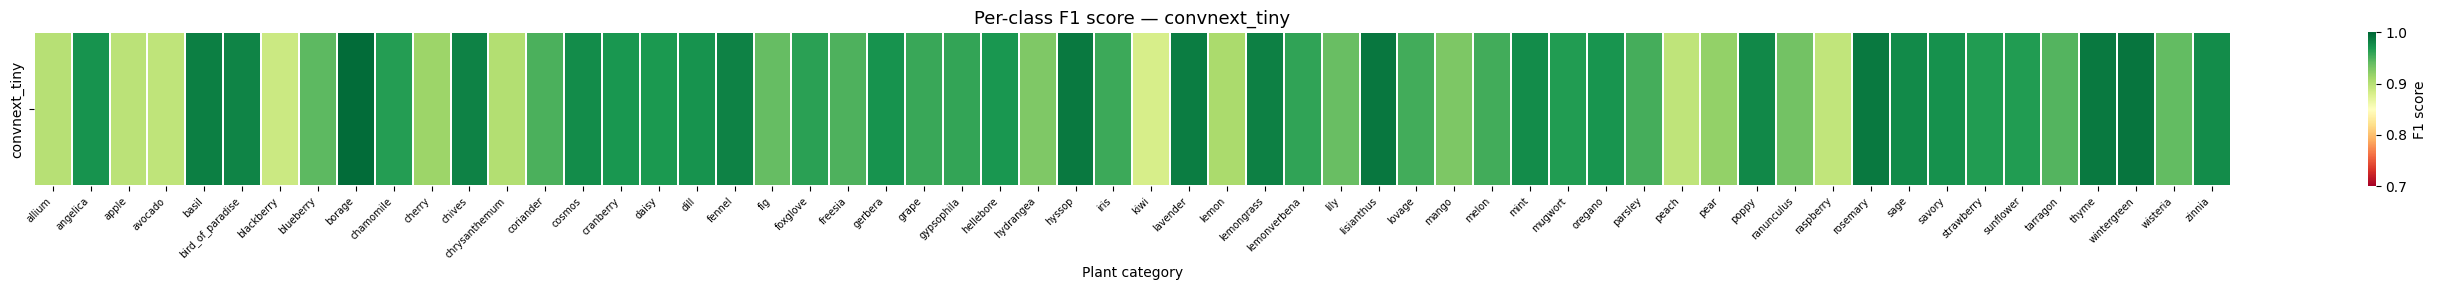

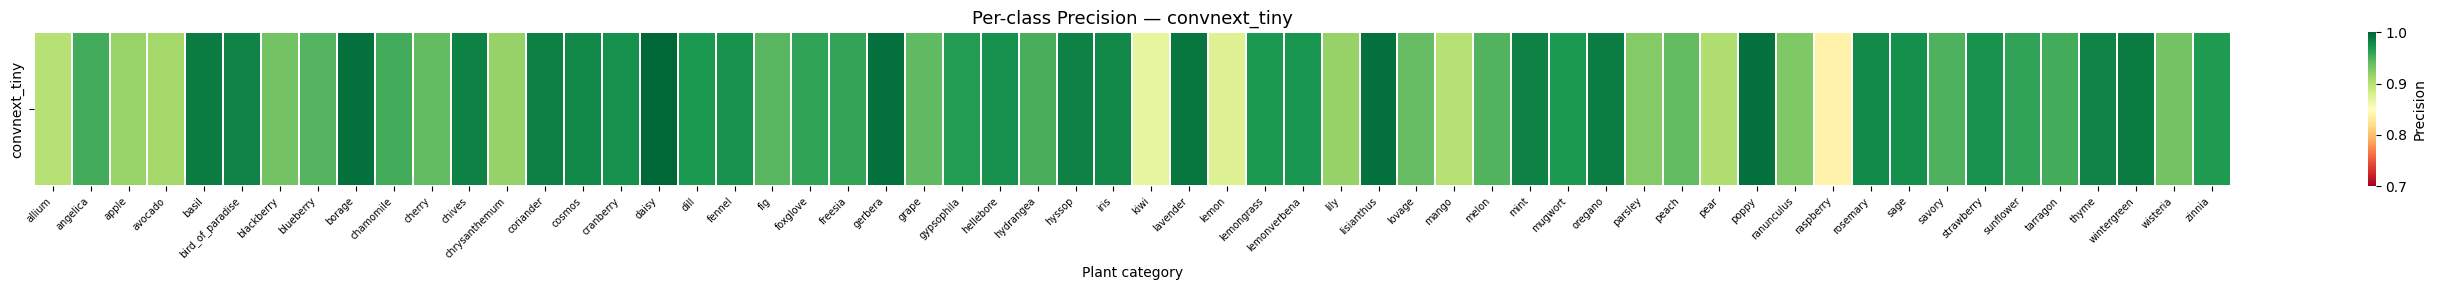

All classes have F1 >= 0.8. Excellent coverage.


In [28]:
# ============================================
# Per-Class F1 and Precision Heatmaps
# ============================================

def plot_metric_heatmap(values, class_names, title, filename, model_label):
    df = pd.DataFrame([values], index=[model_label], columns=class_names)
    fig, ax = plt.subplots(figsize=(28, 3))
    sns.heatmap(df, annot=False, cmap="RdYlGn", vmin=0.7, vmax=1.0,
                linewidths=0.3, ax=ax, cbar_kws={"label": title})
    ax.set_title(f"Per-class {title} — {model_label}", fontsize=13)
    ax.set_xlabel("Plant category")
    ax.set_ylabel("")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()

f1_vals   = f1_score(       y_true_val, y_pred_val, average=None, labels=list(range(num_classes)), zero_division=0)
prec_vals = precision_score(y_true_val, y_pred_val, average=None, labels=list(range(num_classes)), zero_division=0)

plot_metric_heatmap(f1_vals,   class_names, "F1 score",  "val_f1_heatmap.png",        MODEL_KEY)
plot_metric_heatmap(prec_vals, class_names, "Precision", "val_precision_heatmap.png", MODEL_KEY)

# Hard classes (F1 < 0.80)
FAIL_THRESHOLD = 0.80
hard = {class_names[i]: round(f1_vals[i], 3) for i in range(num_classes) if f1_vals[i] < FAIL_THRESHOLD}
if hard:
    print(f"Classes with F1 < {FAIL_THRESHOLD}:")
    for cls, f1 in sorted(hard.items(), key=lambda x: x[1]):
        print(f"  {cls:<25} F1={f1:.3f}  Precision={prec_vals[class_names.index(cls)]:.3f}")
else:
    print(f"All classes have F1 >= {FAIL_THRESHOLD}. Excellent coverage.")

## Step 5 — Held-Out Test Set  *(opened once)*

This is the final, unbiased evaluation.
The test set was locked away before any training and has never influenced
the model weights or checkpoint selection.

> **Compare test_acc to best_val_acc.**
> A small gap (< 1 pp) confirms the model generalises well and that
> val-based checkpoint selection did not overfit to the val distribution.

In [29]:
# ============================================
# Final Evaluation — Held-Out Test Set
# ============================================

_, test_tfm = get_transforms()
test_ds  = ImageFolder(TEST_DIR, transform=test_tfm)
test_ld  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=4, pin_memory=True)

test_model = get_model()
test_model.load_state_dict(torch.load(ckpt_path, map_location=device))
test_model.eval()

y_true_test, y_pred_test = [], []
with torch.no_grad():
    for x, y in test_ld:
        _, predicted = test_model(x.to(device)).max(1)
        y_true_test.extend(y.numpy())
        y_pred_test.extend(predicted.cpu().numpy())

y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)

test_acc  = accuracy_score(y_true_test, y_pred_test)
test_f1   = f1_score(      y_true_test, y_pred_test, average="macro", zero_division=0)
test_prec = precision_score(y_true_test, y_pred_test, average="macro", zero_division=0)
test_rec  = recall_score(  y_true_test, y_pred_test, average="macro", zero_division=0)

print(f"{'='*50}")
print(f"  Model        : {MODEL_KEY}")
print(f"  Test images  : {len(y_true_test)}")
print(f"{'─'*50}")
print(f"  Accuracy     : {test_acc:.4f}")
print(f"  F1  (macro)  : {test_f1:.4f}")
print(f"  Precision    : {test_prec:.4f}")
print(f"  Recall       : {test_rec:.4f}")
print(f"{'─'*50}")
print(f"  Val acc      : {best_acc:.4f}")
print(f"  Gap val-test : {best_acc - test_acc:+.4f}")
print(f"{'='*50}")

  Model        : convnext_tiny
  Test images  : 8841
──────────────────────────────────────────────────
  Accuracy     : 0.9463
  F1  (macro)  : 0.9448
  Precision    : 0.9452
  Recall       : 0.9448
──────────────────────────────────────────────────
  Val acc      : 0.9557
  Gap val-test : +0.0094


                  precision    recall  f1-score   support

          allium       0.85      0.85      0.85       150
        angelica       0.98      0.98      0.98       145
           apple       0.86      0.85      0.86       150
         avocado       0.82      0.81      0.81       150
           basil       0.96      0.98      0.97       168
bird_of_paradise       0.97      0.99      0.98       113
      blackberry       0.92      0.89      0.90       150
       blueberry       0.97      0.99      0.98       150
          borage       0.99      0.99      0.99       164
       chamomile       0.96      0.99      0.97       170
          cherry       0.90      0.87      0.88       143
          chives       0.98      0.98      0.98       237
   chrysanthemum       0.90      0.85      0.87       150
       coriander       0.98      0.92      0.95       136
          cosmos       0.97      0.97      0.97       150
       cranberry       0.97      0.98      0.98       150
           da

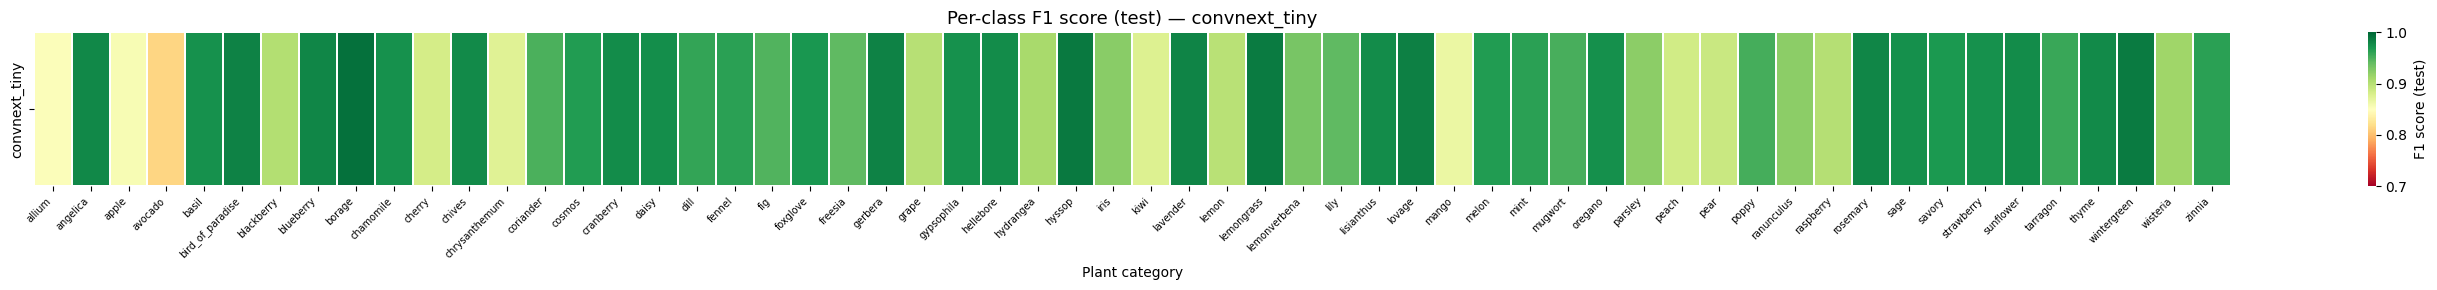

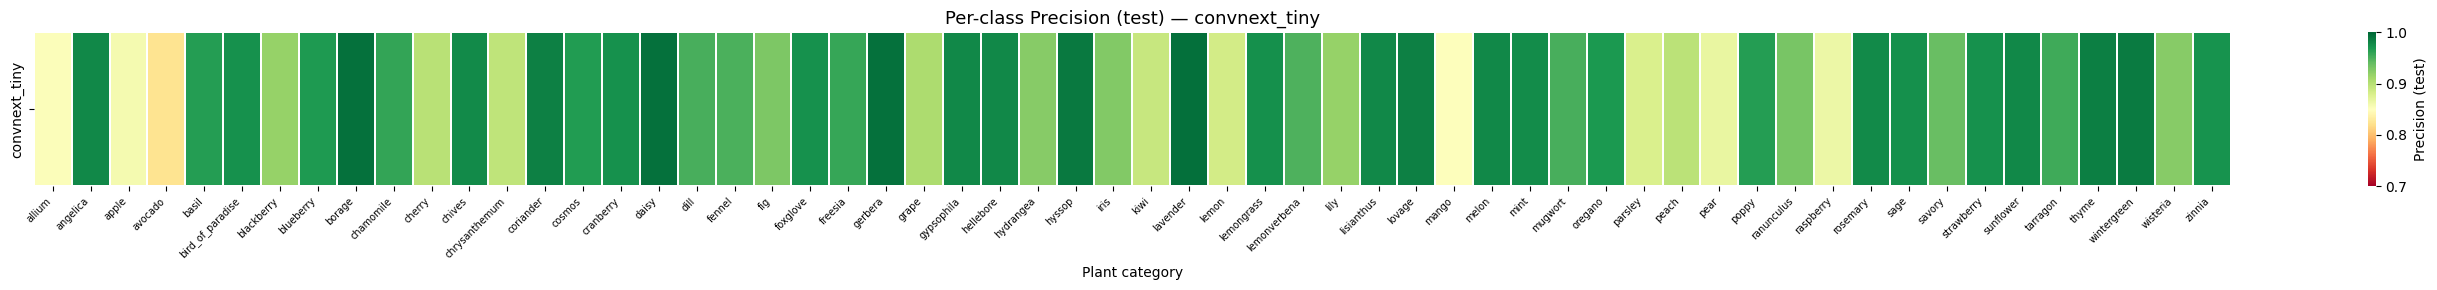

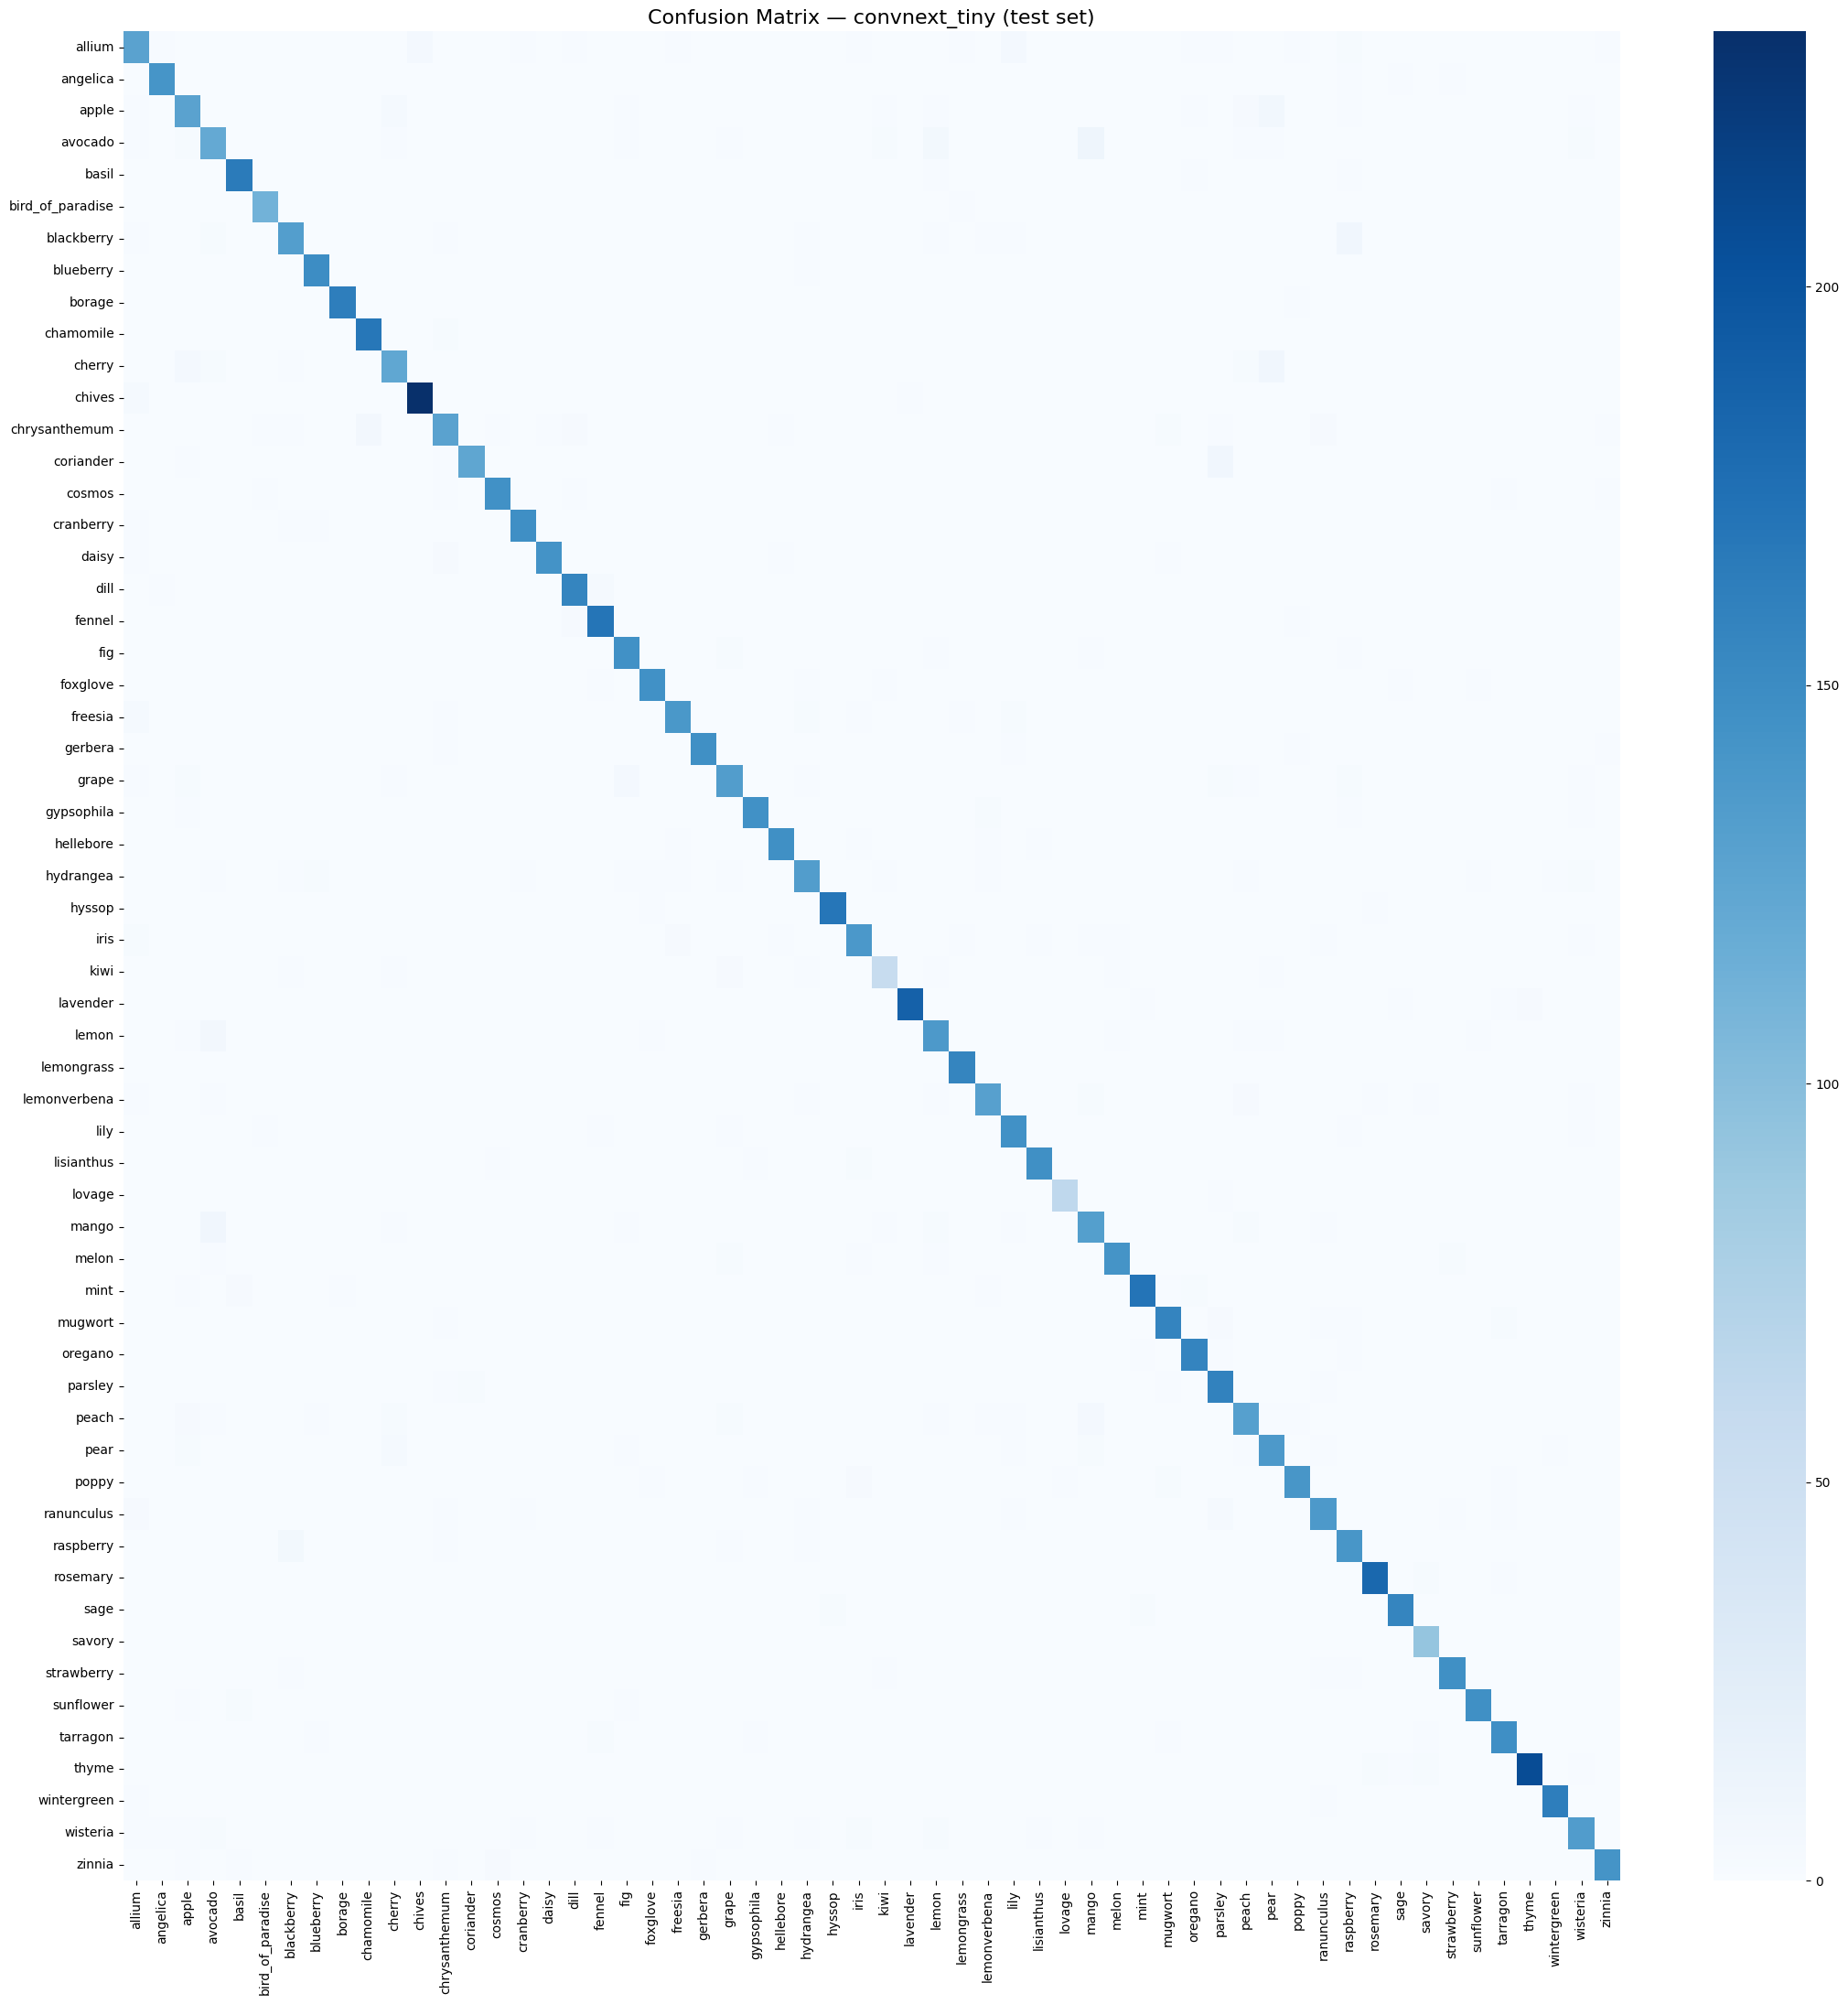

In [30]:
# ============================================
# Per-Class Report + Heatmaps on Test Set
# ============================================

print(classification_report(y_true_test, y_pred_test, target_names=test_ds.classes))

tf1_vals   = f1_score(       y_true_test, y_pred_test, average=None, labels=list(range(num_classes)), zero_division=0)
tprec_vals = precision_score(y_true_test, y_pred_test, average=None, labels=list(range(num_classes)), zero_division=0)

plot_metric_heatmap(tf1_vals,   class_names, "F1 score (test)",  "test_f1_heatmap.png",        MODEL_KEY)
plot_metric_heatmap(tprec_vals, class_names, "Precision (test)", "test_precision_heatmap.png", MODEL_KEY)

# Confusion matrix
cm = confusion_matrix(y_true_test, y_pred_test)
fig, ax = plt.subplots(figsize=(22, 22))
sns.heatmap(cm, annot=False, cmap="Blues", ax=ax,
            xticklabels=test_ds.classes, yticklabels=test_ds.classes)
ax.set_title(f"Confusion Matrix — {MODEL_KEY} (test set)", fontsize=16)
plt.tight_layout()
plt.savefig("test_confusion_matrix.png", dpi=150)
plt.show()

In [31]:
# ============================================
# Log Test Results to W&B
# ============================================

report = classification_report(y_true_test, y_pred_test,
                                target_names=test_ds.classes, output_dict=True)
test_run = wandb.init(project="certification", name=f"{MODEL_KEY}_test_eval",
                      reinit="finish_previous")
wandb.log({
    "test_accuracy":         test_acc,
    "test_f1_macro":         test_f1,
    "test_precision_macro":  test_prec,
    "test_recall_macro":     test_rec,
    "val_test_gap":          best_acc - test_acc,
    "classification_report": report,
    "test_f1_heatmap":       wandb.Image("test_f1_heatmap.png"),
    "test_precision_heatmap":wandb.Image("test_precision_heatmap.png"),
    "test_confusion_matrix": wandb.Image("test_confusion_matrix.png"),
})
test_run.finish()
print("All results logged to W&B.")

test_accuracy,▁
test_f1_macro,▁
test_precision_macro,▁
test_recall_macro,▁
val_test_gap,▁
test_accuracy,0.94627
test_f1_macro,0.94478
test_precision_macro,0.94521
test_recall_macro,0.9448
val_test_gap,0.00945


All results logged to W&B.
